Data Visualization

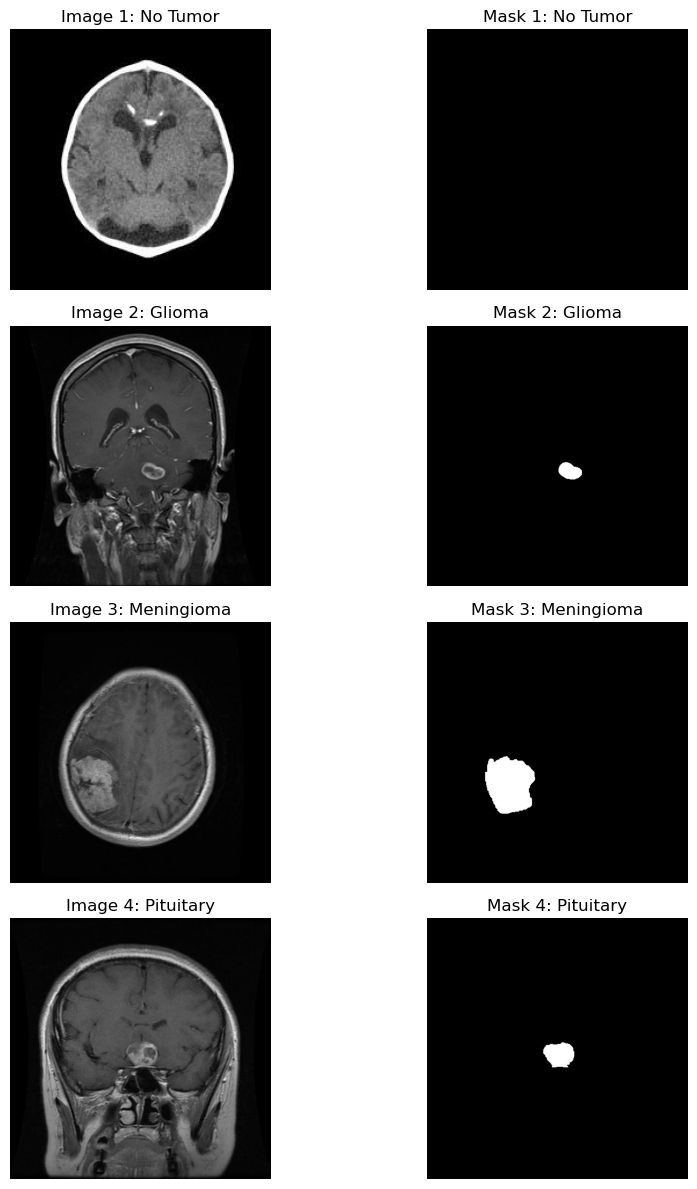

In [1]:
import cv2
import matplotlib.pyplot as plt

# Function to load and verify images
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Unable to load image at {path}")
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for correct visualization

# Define file paths
paths = [
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\image\0\Tr-no_0010.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\mask\0\Tr-no_0010_m.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\image\1\Tr-gl_0014.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\mask\1\Tr-gl_0014_m.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\image\2\Tr-me_0010.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\mask\2\Tr-me_0010_m.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\image\3\Tr-pi_0010.jpg",
    r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset\mask\3\Tr-pi_0010_m.jpg"
]

# Load images
images = [load_image(path) for path in paths]

# Titles for each image
titles = [
    "Image 1: No Tumor", "Mask 1: No Tumor",
    "Image 2: Glioma", "Mask 2: Glioma",
    "Image 3: Meningioma", "Mask 3: Meningioma",
    "Image 4: Pituitary", "Mask 4: Pituitary"
]

# Create subplots
fig, axs = plt.subplots(4, 2, figsize=(10, 12))

# Plot images with error handling
for i, ax in enumerate(axs.flat):
    if images[i] is not None:
        ax.imshow(images[i])
    else:
        ax.text(0.5, 0.5, "Image Not Found", ha='center', va='center', fontsize=12, color='red')
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.show()


Data Preprocessing

In [ ]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from albumentations import HorizontalFlip, VerticalFlip, Rotate, Compose

DATASET_PATH = r"D:\Pfe\Code\Dataset\archive (2)\Brain Tumor Segmentation Dataset"
CLASSES = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
TARGET_SIZE = (128, 128)

# Augmentation function
def augment_data(image, mask, tumor_type):
    if tumor_type in [1, 2, 3]:  
        transform = Compose([
            HorizontalFlip(p=1),
            VerticalFlip(p=1),
            Rotate(limit=45, p=1)
        ])
        augmented = transform(image=image, mask=mask)
        return augmented["image"], augmented["mask"]
    
    return image, mask  

# Load dataset
def load_data(data_path, classes, target_size):
    images = []
    masks = []
    labels = []

    for class_index, class_name in enumerate(classes):
        image_folder = os.path.join(data_path, 'image', str(class_index))
        mask_folder = os.path.join(data_path, 'mask', str(class_index))
        
        if not os.path.exists(image_folder) or not os.path.exists(mask_folder):
            continue

        for image_name in tqdm(os.listdir(image_folder), desc=f"Loading {class_name}"):
            if image_name.endswith(('.jpg', '.png')):
                image_path = os.path.join(image_folder, image_name)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if image is None:
                    continue
                
                image = cv2.resize(image, target_size)
                image = image / 255.0  

                mask_name = image_name.replace('.jpg', '_m.jpg').replace('.png', '_m.png')
                mask_path = os.path.join(mask_folder, mask_name)

                if os.path.exists(mask_path):
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if mask is None:
                        continue

                    mask = cv2.resize(mask, target_size)
                    mask = mask / 255.0  

                    # Add original image and mask
                    images.append(image)
                    masks.append(mask)
                    labels.append(class_index)
                    
                    
                    if class_index in [1, 2, 3]:  
                        aug_image, aug_mask = augment_data(image, mask, class_index)
                        images.append(aug_image)
                        masks.append(aug_mask)
                        labels.append(class_index)
                    
    images = np.array(images, dtype=np.float32).reshape(-1, 128, 128, 1)
    masks = np.array(masks, dtype=np.float32).reshape(-1, 128, 128, 1)
    labels = np.array(labels, dtype=np.int32)

    return images, masks, labels

# Data Splitting
def split_data(images, masks, labels, test_size=0.2, val_size=0.1):
    Img_train, Img_test, label_train, label_test, mask_train, mask_test = train_test_split(
        images, labels, masks, test_size=test_size, random_state=42, stratify=labels
    )

    Img_train, Img_val, label_train, label_val, mask_train, mask_val = train_test_split(
        Img_train, label_train, mask_train, test_size=val_size, random_state=42, stratify=label_train
    )
    
    return Img_train, Img_val, Img_test, label_train, label_val, label_test, mask_train, mask_val, mask_test

# Main execution
if __name__ == "__main__":
    images, masks, labels = load_data(DATASET_PATH, CLASSES, TARGET_SIZE)
    print(f"number of images: {images.shape[0]}, number of masks: {masks.shape[0]}, number of Labels: {labels.shape[0]}")

    Img_train, Img_val, Img_test, label_train, label_val, label_test, mask_train, mask_val, mask_test = split_data(
        images, masks, labels, test_size=0.2, val_size=0.1
    )

    print(f"Training data: {Img_train.shape[0]}")
    print(f"Validation data: {Img_val.shape[0]}")
    print(f"Test data: {Img_test.shape[0]}")


d:\anaconda3\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
Loading pituitary_tumor: 100%|██████████| 994/994 [00:12<00:00, 81.48it/s]


number of images: 6879, number of masks: 6879, number of Labels: 6879
Training data: 4952
Validation data: 551
Test data: 1376


Create Model

In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose, 
                                     concatenate, BatchNormalization, Dropout)
from tensorflow.keras.regularizers import l2

def unet_model(input_size=(128, 128, 1)):
    inputs = Input(input_size)
    reg = l2(0.0001)  

    # Encoder (Down Sampling)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    p1 = Dropout(0.3)(p1)  

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    p2 = Dropout(0.3)(p2)  

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c3)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    p3 = Dropout(0.4)(p3)  

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p3)
    c4 = BatchNormalization()(c4)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c4)
    c4 = BatchNormalization()(c4)
    p4 = MaxPooling2D((2, 2))(c4)
    p4 = Dropout(0.4)(p4)  

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p4)
    c5 = BatchNormalization()(c5)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c5)
    c5 = BatchNormalization()(c5)
    c5 = Dropout(0.5)(c5)  

    # Decoder (Up Sampling)
    u6 = Conv2DTranspose(512, (2, 2), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u6)
    c6 = BatchNormalization()(c6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c6)
    c6 = BatchNormalization()(c6)

    u7 = Conv2DTranspose(256, (2, 2), strides=(2,2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u7)
    c7 = BatchNormalization()(c7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c7)
    c7 = BatchNormalization()(c7)

    u8 = Conv2DTranspose(128, (2, 2), strides=(2,2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u8)
    c8 = BatchNormalization()(c8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c8)
    c8 = BatchNormalization()(c8)

    u9 = Conv2DTranspose(64, (2, 2), strides=(2,2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u9)
    c9 = BatchNormalization()(c9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c9)
    c9 = BatchNormalization()(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs, outputs)
    return model


In [3]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) / 
                (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth))

model = unet_model()
model.compile(optimizer=Adam(learning_rate=0.0001), loss=dice_loss, metrics=["accuracy"])
model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_5[0][0]  

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [ ]:

import pickle


from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  
    patience=3,  
    min_lr=1e-6  
)


history = model.fit(
    Img_train, mask_train,
    validation_data=(Img_val, mask_val),
    epochs=50,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]  
)



with open('history1.pkl', 'wb') as f:
    pickle.dump(history.history, f)

model.save("best_model.h5")
print("Model and History Saved 100%")





Epoch 1/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2298s 3s/step - accuracy: 0.8848 - loss: 0.7624 - val_accuracy: 0.9710 - val_loss: 0.7505
Epoch 2/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2275s 3s/step - accuracy: 0.9899 - loss: 0.4092 - val_accuracy: 0.9903 - val_loss: 0.3893
Epoch 3/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2348s 3s/step - accuracy: 0.9911 - loss: 0.3298 - val_accuracy: 0.9908 - val_loss: 0.3452
Epoch 4/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 5690s 7s/step - accuracy: 0.9916 - loss: 0.2941 - val_accuracy: 0.9903 - val_loss: 0.4106
Epoch 5/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 26661s 31s/step - accuracy: 0.9922 - loss: 0.2505 - val_accuracy: 0.9915 - val_loss: 0.2647
Epoch 6/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2207s 3s/step - accuracy: 0.9926 - loss: 0.2389 - val_accuracy: 0.9926 - val_loss: 0.2071
Epoch 7/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2206s 3s/step - accuracy: 0.9927 - loss: 0.2167 - val_accuracy: 0.9921 - val_loss: 0.2271
Epoch 8/25
848/848 ━━━━━━━━━━━━━━━━━━━━ 2211s 3s/step - accuracy: 0.9930 - loss: 0.2108 

Model Saved 100%


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


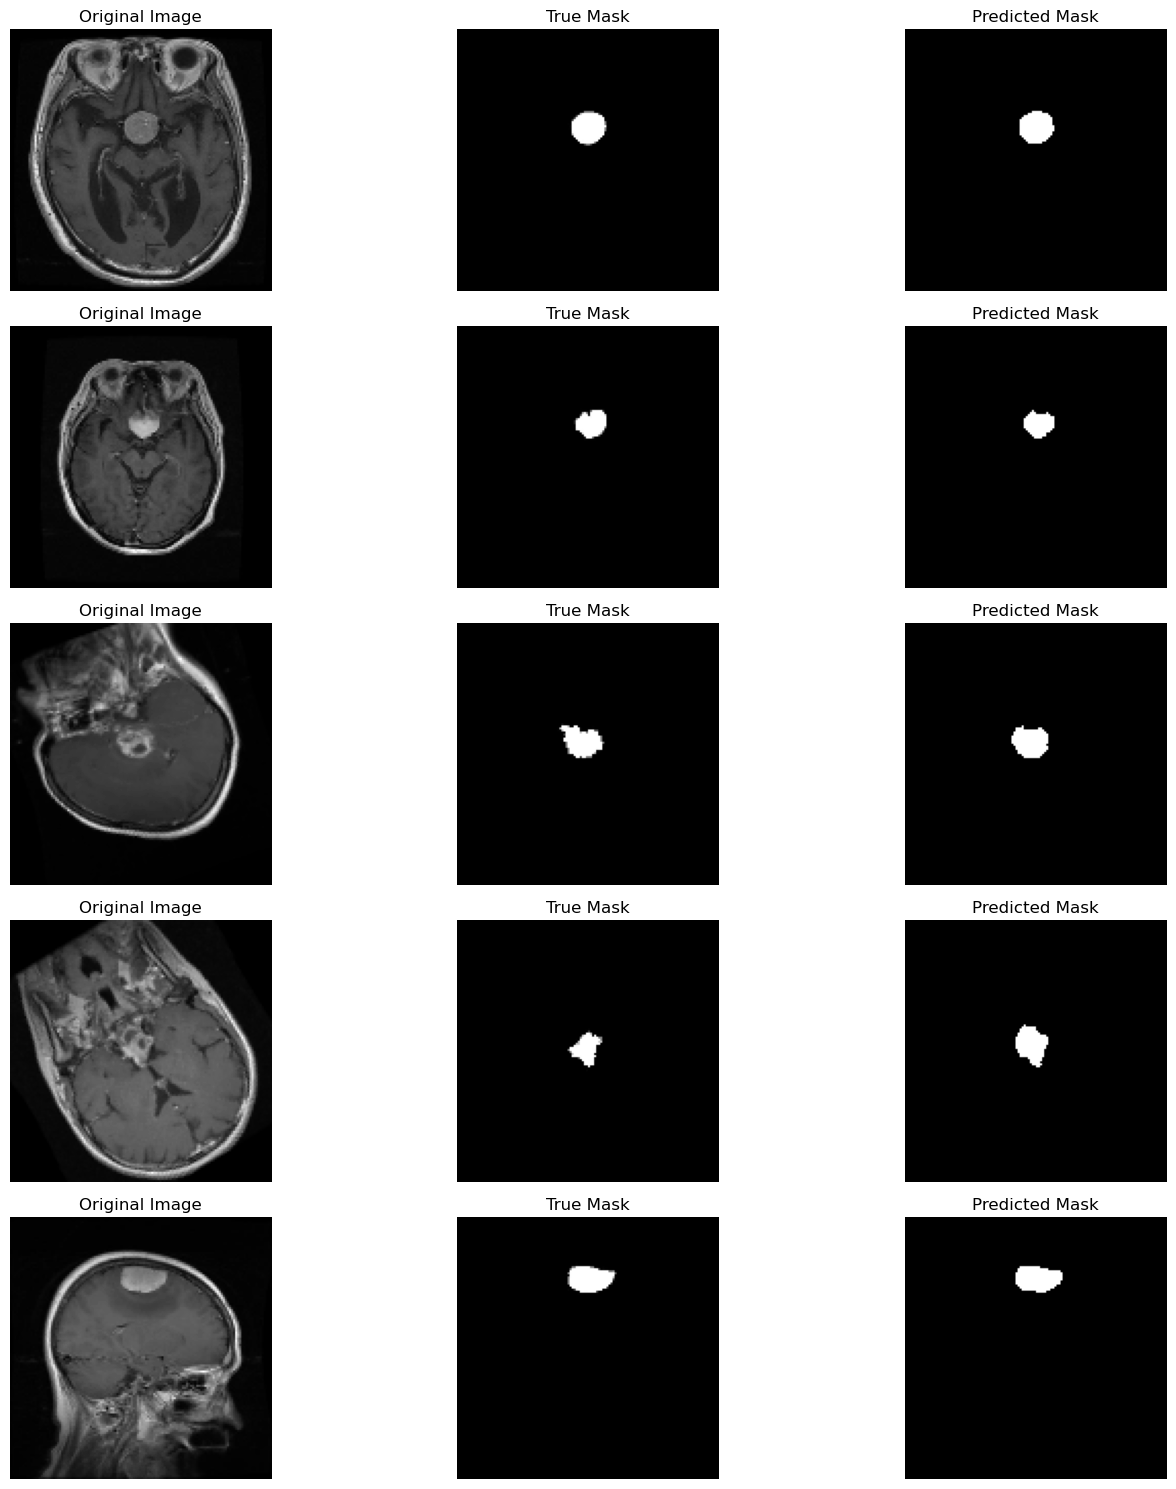

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def test_model(model, Img_test, mask_test, num_samples=5):
  
    indices = np.random.choice(len(Img_test), num_samples, replace=False)  

    plt.figure(figsize=(15, num_samples * 3))

    for i, idx in enumerate(indices):
        test_image = Img_test[idx]
        true_mask = mask_test[idx]

        
        test_image_input = np.expand_dims(test_image, axis=0)

        
        pred_mask = model.predict(test_image_input)[0]  

        
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

        
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(test_image, cmap='gray')
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(true_mask, cmap='gray')
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

model = unet_model(input_size=(128, 128, 1))


model.load_weights(r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Saves\Seg2\model1 (1).h5")


model.compile(optimizer=Adam(), loss=dice_loss, metrics=['accuracy'])

test_model(model, Img_test, mask_test, num_samples=5)


In [ ]:
from tensorflow.keras.optimizers import Adam



model = unet_model(input_size=(128, 128, 1))


model.load_weights(r"C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Saves\Seg2\model1 (1).h5")


model.compile(optimizer=Adam(), loss=dice_loss, metrics=['accuracy'])


test_loss, test_accuracy = model.evaluate(Img_test, mask_test, batch_size=16)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

86/86 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.9934 - loss: 0.1804
Test Accuracy: 0.9936
Test Loss: 0.1795


In [ ]:
import pickle

with open(r'C:\Users\MSI GAMER\Desktop\Third Year\Pfe\Code\Saves\Seg2\history .pkl', 'rb') as file:
    history = pickle.load(file)


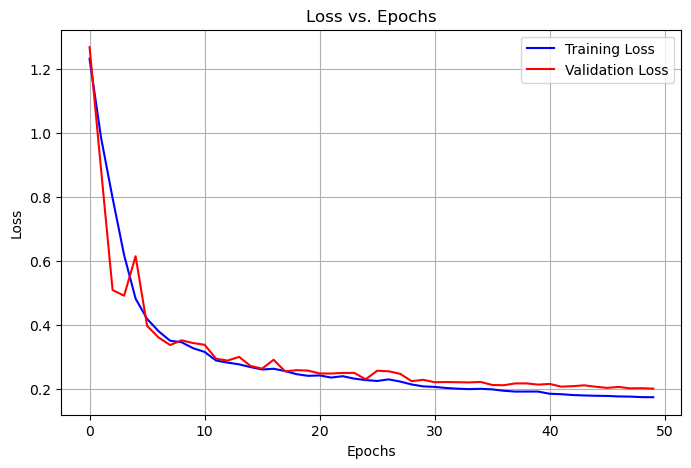

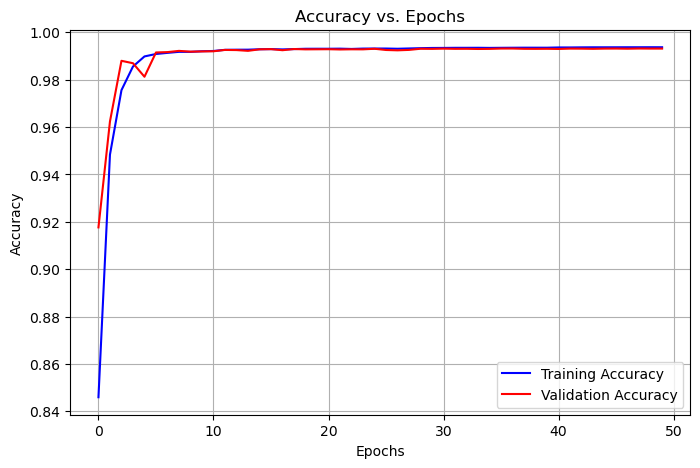

In [7]:
import matplotlib.pyplot as plt


if hasattr(history, 'history'):  
    history = history.history  


train_loss = history['loss']
val_loss = history['val_loss']


plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.legend()
plt.grid()
plt.show()


train_acc = history.get('accuracy', history.get('acc'))  
val_acc = history.get('val_accuracy', history.get('val_acc'))


plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='red')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epochs')
plt.legend()
plt.grid()
plt.show()
